# OpenMRG - Gothenburg, Sweden

364 commercial microwave links (CMLs) run by Ericsson, a C-band radar
composite and eleven rain gauges over Gothenburg, published by SMHI:
Andersson et al. (2022), [doi:10.5281/zenodo.6673750](https://doi.org/10.5281/zenodo.6673750),
CC BY-SA 4.0. The example repository carries two cuts of it
([`OpenMRG/`](https://github.com/OpenSenseAction/opensense_example_data/tree/main/OpenMRG)):

| subset | span | CML | radar | gauges |
|---|---|---|---|---|
| `8d` | 2015-07-22 - 07-29, 1 min | `tsl`, `rsl` and a reference rain rate `R` | 5-min rate | 10 municipal (1 min), 1 SMHI (15 min) |
| `5min_2h` | 2015-07-25 12:30 - 15:00 | processed `R` only, 5 min | 5-min accumulation | same, 5 min |

`5min_2h` is the `mergeplg` example data: rain rates are already retrieved,
so it is for merging, not for retrieval.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import poligrain as plg

from core import viz_style as vs
from core.opensense import example_data, plots

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)

## The 8-day subset

Radar and gauges are small. The CML file is 1.2 GB in memory, so it is read
one day at a time with `time=`; 25 July carries the storm the `5min_2h`
subset was cut from.

In [2]:
ref = example_data.load("openmrg", "8d", components=("radar", "gauge_municipal", "gauge_smhi"),
                       verbose=False)
cml = example_data.load("openmrg", "8d", components=("cml",), verbose=False,
                        time=slice("2015-07-25", "2015-07-25"))["cml"]
radar, gauges, smhi = ref["radar"], ref["gauge_municipal"], ref["gauge_smhi"]
cml

<xarray.Dataset> Size: 151MB
Dimensions:        (sublink_id: 2, cml_id: 364, time: 8640)
Coordinates: (12/18)
  * sublink_id     (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id         (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
  * time           (time) datetime64[ns] 69kB 2015-07-25 ... 2015-07-25T23:59:50
    site_0_lat     (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.65 57.66 57.71
    site_0_lon     (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.12 12.03 12.01
    site_1_lat     (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.66 57.63 57.71
    ...             ...
    site_0_x       (cml_id) float64 3kB 6.785e+05 6.776e+05 ... 6.792e+05
    site_0_y       (cml_id) float64 3kB 6.4e+06 6.402e+06 ... 6.394e+06 6.4e+06
    site_1_x       (cml_id) float64 3kB 6.783e+05 6.77e+05 ... 6.778e+05
    site_1_y       (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.401e+06
    x              (cml_id) float64 3kB 6.784e+05 6.773e+05 ... 6.785e+05
    y              (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.4e+06
Data variables:
    tsl            (time, sublink_id, cml_id) float64 50MB 1.0 0.0 ... 16.0 0.0
    rsl            (time, sublink_id, cml_id) float64 50MB -46.0 -41.0 ... -49.2
    R              (sublink_id, cml_id, time) float64 50MB 0.0 0.0 ... 0.0 0.0
Attributes: (12/14)
    title:                 OpenMRG-CML
    version:               1.1
    source:                Swedish Meteorological and Hydrological Institute ...
    contact:               hydro.fou@smhi.se, jafet.andersson@smhi.se
    license:               https://creativecommons.org/licenses/by-sa/4.0
    doi:                   https://doi.org/10.5281/zenodo.6673750
    ...                    ...
    institution:           NA
    date:                  NA
    history:               NA
    naming convention:     NA
    license restrictions:  NA
    reference:             NA

### Link metadata, and the frequency trap

The file stores `frequency` in **MHz with no `units` attribute**. Read as GHz,
7456 would clamp every link to the top of the ITU-R P.838 table and the
retrieval would return almost no rain, without any error. `load()` adds
`frequency_ghz` and `length_km`, deciding the unit from the attribute or,
when there is none, from the magnitude.

frequency as stored : 7456 .. 38682   units='(none)'
frequency_ghz       : 7.46 .. 38.68 GHz
length_km           : 0.14 .. 15.23 km
polarization        : ['horizontal', 'vertical']


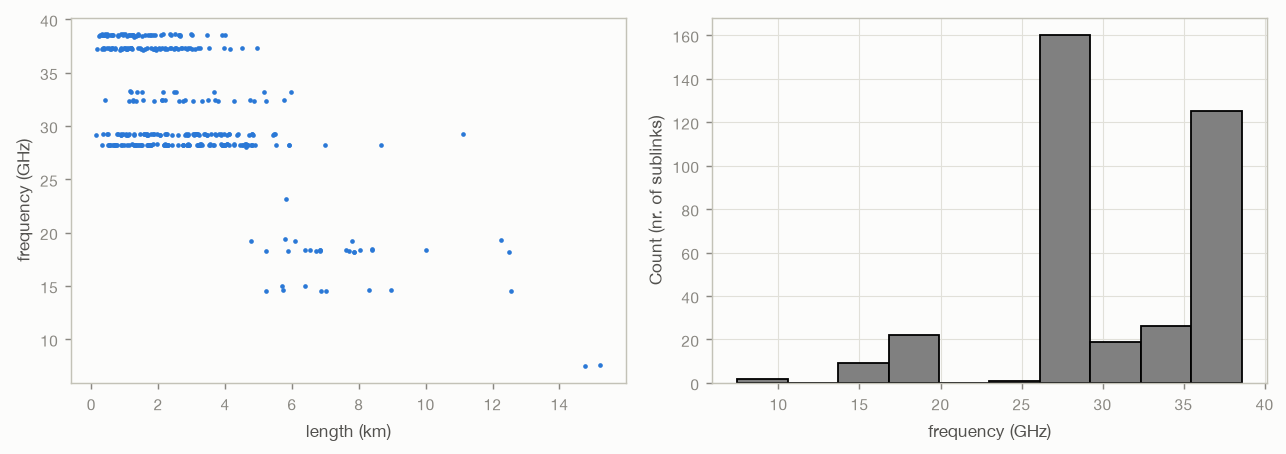

In [3]:
print(f"frequency as stored : {float(cml.frequency.min()):.0f} .. {float(cml.frequency.max()):.0f}"
      f"   units={cml.frequency.attrs.get('units', '(none)')!r}")
print(f"frequency_ghz       : {float(cml.frequency_ghz.min()):.2f} .. {float(cml.frequency_ghz.max()):.2f} GHz")
print(f"length_km           : {float(cml.length_km.min()):.2f} .. {float(cml.length_km.max()):.2f} km")
print(f"polarization        : {sorted(set(np.asarray(cml.polarization).ravel().tolist()))}")
plots.metadata(cml);

### The network at the peak of the storm

Radar frame at the time of the largest domain-mean rain rate on 25 July, links
on top, gauges as dots.

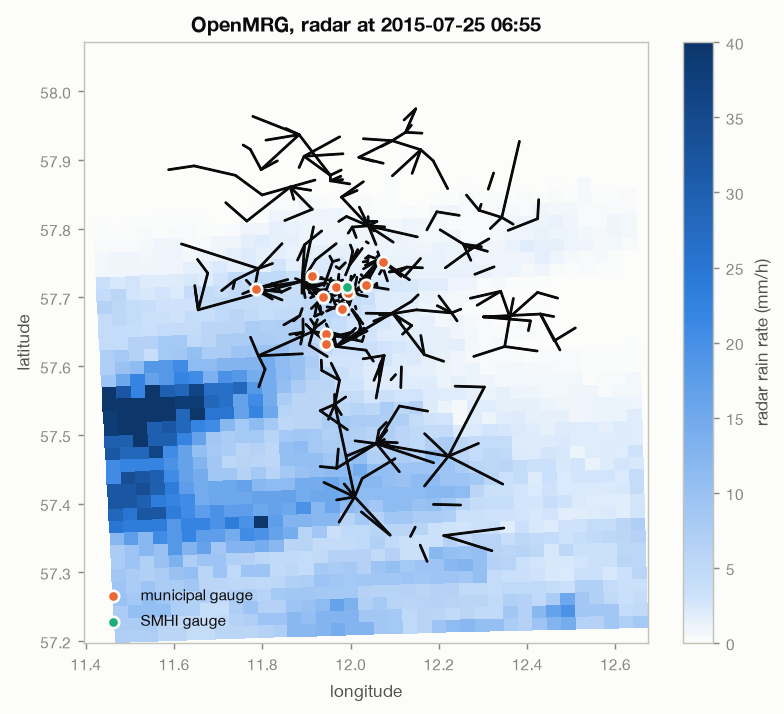

In [4]:
day = radar.R.sel(time="2015-07-25")
t_peak = day.mean(("y", "x")).idxmax("time").values
plots.network(radar.R.sel(time=t_peak), cml,
              gauges={"municipal gauge": gauges, "SMHI gauge": smhi},
              title=f"OpenMRG, radar at {pd.Timestamp(t_peak):%Y-%m-%d %H:%M}");

### One link

Total path loss `tsl - rsl` rises when rain attenuates the signal. The file
also carries a reference rain rate `R` retrieved by the OpenSense community;
FieldSense's own retrieval (`core.opensense.retrieval`) is validated against it
in `projects/opensense_pipeline/src/validate_retrieval.py`.

The link shown is the one under the most radar rain around the peak
(`poligrain.spatial.GridAtLines` averages the radar along each path), and the
radar path average is drawn with the link's `R`. Picking by the link's own
`R` instead tends to find a link with a stuck or shifted level, not rain.

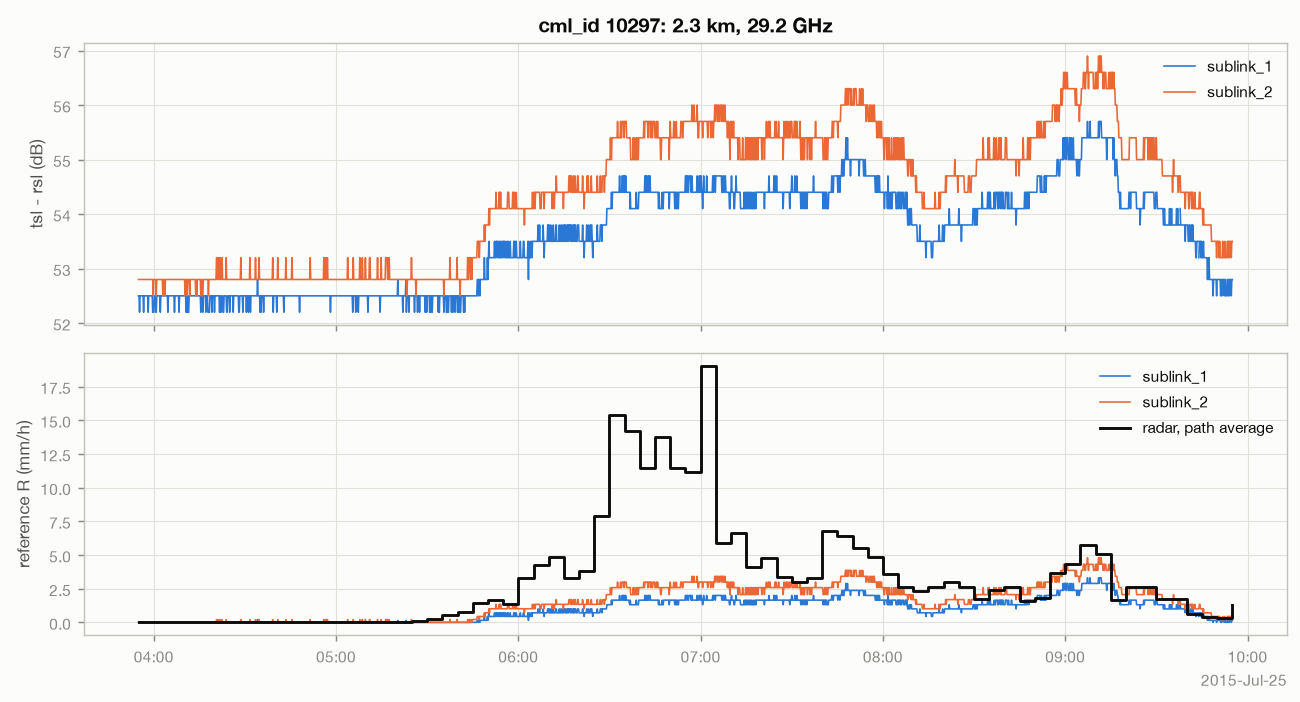

In [5]:
window = slice(pd.Timestamp(t_peak) - pd.Timedelta("3h"), pd.Timestamp(t_peak) + pd.Timedelta("3h"))
radar_path = plg.spatial.GridAtLines(radar.R, cml)(radar.R.sel(time=window))
complete = (cml.rsl.sel(time=window).notnull().mean(("time", "sublink_id")) > 0.95).values
wettest = int(radar_path.sum("time").where(complete).argmax())
link = cml.isel(cml_id=wettest)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for s, c in zip(link.sublink_id.values, (C1, C2)):
    tl = (link.tsl - link.rsl).sel(sublink_id=s, time=window)
    tl.plot(ax=axes[0], color=c, lw=0.9, label=str(s))
    link.R.sel(sublink_id=s, time=window).plot(ax=axes[1], color=c, lw=0.9, label=str(s))
radar_path.isel(cml_id=wettest).plot(ax=axes[1], color=vs.INK_PRIMARY, lw=1.6,
                                     drawstyle="steps-post", label="radar, path average")
axes[1].legend()
axes[0].set(ylabel="tsl - rsl (dB)", xlabel="",
            title=f"cml_id {int(link.cml_id)}: {float(link.length_km):.1f} km, "
                  f"{float(link.frequency_ghz.isel(sublink_id=0)):.1f} GHz")
axes[1].set(ylabel="reference R (mm/h)", xlabel="", title="")
axes[0].legend(); fig.tight_layout()

### Radar against gauges, 8 days

Hourly rain at each gauge: the gauge itself against the radar pixel above it
(`poligrain.spatial.GridAtPoints`, on the projected coordinates `load()`
added). The municipal gauges report 1-minute amounts; `load()` turned them
into mm/h as `R`.

415 wet station-hours, correlation 0.49, radar/gauge total 0.89


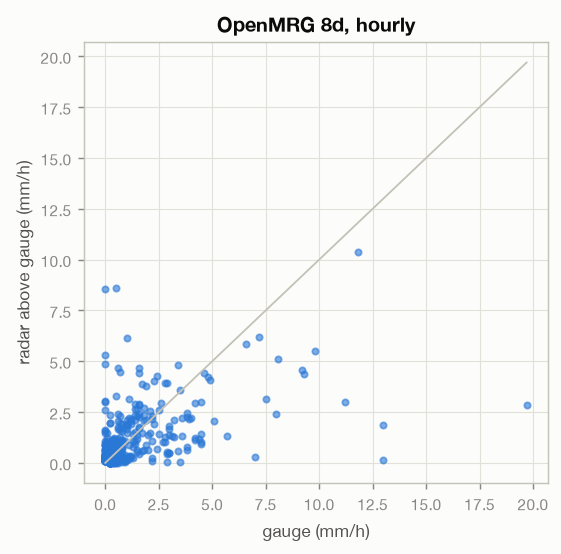

In [6]:
at_gauges = plg.spatial.GridAtPoints(radar.R, gauges.R, nnear=1)(radar.R, gauges.R)
hourly = pd.DataFrame({
    "gauge": gauges.R.resample(time="1h").mean().values.ravel(),
    "radar": at_gauges.resample(time="1h").mean().transpose("time", "id").values.ravel(),
}).dropna()
wet = hourly[(hourly.gauge > 0.1) | (hourly.radar > 0.1)]
print(f"{len(wet)} wet station-hours, correlation {wet.corr().iloc[0, 1]:.2f}, "
      f"radar/gauge total {wet.radar.sum() / wet.gauge.sum():.2f}")

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(wet.gauge, wet.radar, s=12, color=C1, alpha=0.6)
lim = float(max(wet.max()))
ax.plot([0, lim], [0, lim], color=vs.BASELINE, lw=1)
ax.set(xlabel="gauge (mm/h)", ylabel="radar above gauge (mm/h)",
       title="OpenMRG 8d, hourly");

## The 2.5-hour, 5-minute subset

Everything already on one 5-minute axis: CML rain rate per link (no signal
levels), the radar as a 5-minute accumulation, and the gauges. `load()`
converts the radar's `units: "sum 5min"` to mm/h and renames the gauges'
`station_id` dimension to the `id` every other point file uses.

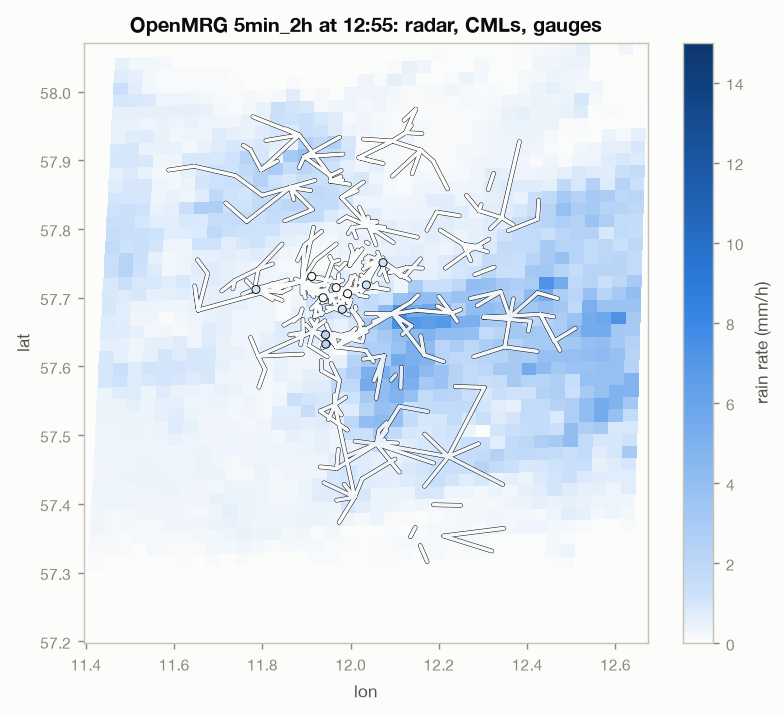

In [7]:
mrg = example_data.load("openmrg", "5min_2h", verbose=False)
t = mrg["radar"].R.mean(("y", "x")).idxmax("time").values
fig, ax = plt.subplots(figsize=(7, 6))
plg.plot_map.plot_plg(da_grid=mrg["radar"].R.sel(time=t),
                      da_cmls=mrg["cml"].R.sel(time=t),
                      da_gauges=mrg["gauge_municipal"].R.sel(time=t),
                      vmin=0, vmax=15, cmap=vs.CMAP_RAIN, ax=ax,
                      colorbar_label="rain rate (mm/h)",
                      kwargs_cmls_plot={"line_width": 2.0})
ax.set_title(f"OpenMRG 5min_2h at {pd.Timestamp(t):%H:%M}: radar, CMLs, gauges");